### Clutser to show the active and passive customers to show frequency

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [2]:
df = pd.read_excel("bank_data_cleaned.xlsx")

In [3]:
features_activity = ["purchases", "purchases_frequency", "balance_frequency"]

X = df[features_activity] # using relevant features for clustering in this case - customer activity related features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # standardize features for better clustering performance

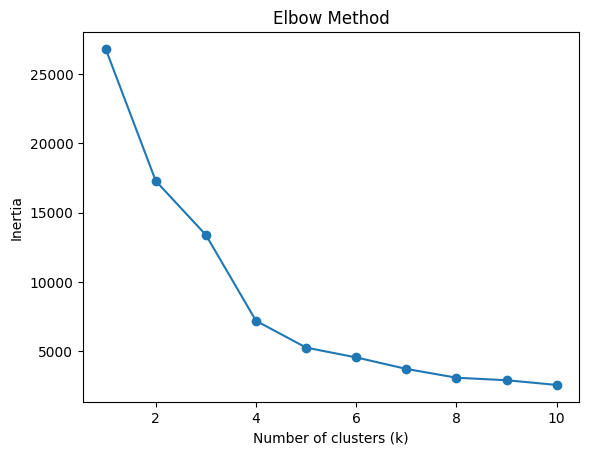

In [5]:
# Determine optimal number of clusters using Elbow method
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [6]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.448
k=3, silhouette score=0.460
k=4, silhouette score=0.560
k=5, silhouette score=0.561
k=6, silhouette score=0.516


#### The elbow method shows a clear decrease in inertia up to k=4, after which the curve starts to flatten. 

#### The silhouette score is highest for k=4 and k=5, but the improvement from k=4 to k=5 is minimal.

#### Therefore, k=4 is chosen as it provides a good balance between cluster quality and interpretability.

In [7]:
# Based on the Elbow method and silhouette scores, we can choose k=4 for clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df["activity_cluster"] = kmeans.fit_predict(X_scaled) 

In [8]:
df["activity_cluster"].value_counts()

activity_cluster
0    3879
1    3524
3    1396
2     144
Name: count, dtype: int64

#### Cluster 2 is pretty small, maybe 4 clusters are to many. Try first with 4 and if it´s not working then I will go down to 3 clusters

In [9]:
df.groupby("activity_cluster")[features_activity].mean() # analyze cluster centers to understand characteristics of each cluster

,purchases,purchases_frequency,balance_frequency
activity_cluster,,,
0,1516.874947,0.880640,0.970264
1,213.172778,0.127354,0.968270
2,12792.383542,0.919339,0.980997
3,358.606791,0.279576,0.379742


In [10]:
cluster_names = {
    0: "Ride or die customers",
    1: "Ghost mode",
    2: "VIP big spenders",
    3: "Treat yourself sometimes"
}

df["activity_cluster_name"] = df["activity_cluster"].map(cluster_names) # map cluster labels to descriptive names for better interpretability

#### Cluster names are intentionally descriptive to make interpretation more intuitive.

In [11]:
df["purchases"] = pd.to_numeric(df["purchases"], errors="coerce")
df["purchases_frequency"] = pd.to_numeric(df["purchases_frequency"], errors="coerce") # ensure numeric data for visualization

In [12]:
df = df.dropna(subset=["purchases", "purchases_frequency"]) # drop rows with missing values in key features to avoid issues in visualization

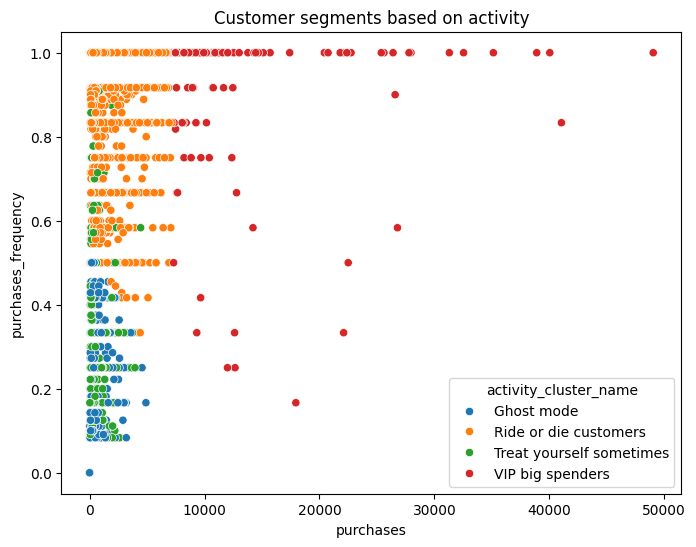

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="purchases",
    y="purchases_frequency",
    hue="activity_cluster_name"
)

plt.title("Customer segments based on activity")
plt.show()

#### Try with 3 cluster insted because the "VIP big spenders" is pretty small just to see

In [14]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)
df["activity_cluster_3"] = kmeans_3.fit_predict(X_scaled)

In [15]:
df["activity_cluster_3"].value_counts()

activity_cluster_3
1    4695
0    4101
2     147
Name: count, dtype: int64

In [16]:
df.groupby("activity_cluster_3")[features_activity].mean()

,purchases,purchases_frequency,balance_frequency
activity_cluster_3,,,
0,1466.999100,0.865182,0.965031
1,233.926961,0.149977,0.797736
2,12676.508231,0.919852,0.981385


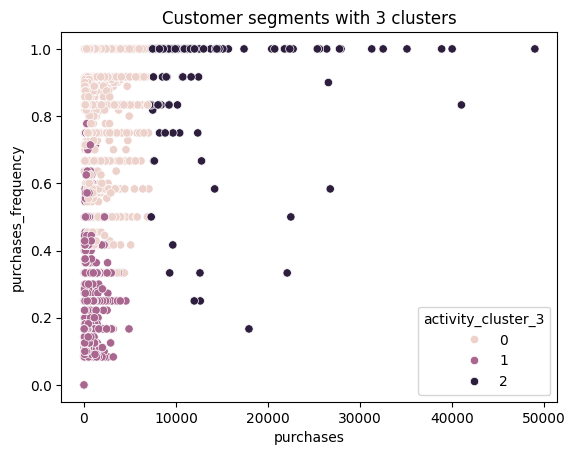

In [17]:
sns.scatterplot(
    data=df,
    x="purchases",
    y="purchases_frequency",
    hue="activity_cluster_3"
)

plt.title("Customer segments with 3 clusters")
plt.show()

#### The comparsion with k=3 doesn´t make it better, because cluster 2 is significantly smaller than the others. K=4 is preferred because it captures more nuanced diffrences in the clusters

### Clutser to show the active and passive customers depending on spender vs indebted customers 

In [18]:
features_spending = ["purchases", "balance", "credit_limit"]

X = df[features_spending] # using relevant features for clustering in this case - customer spending related features

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

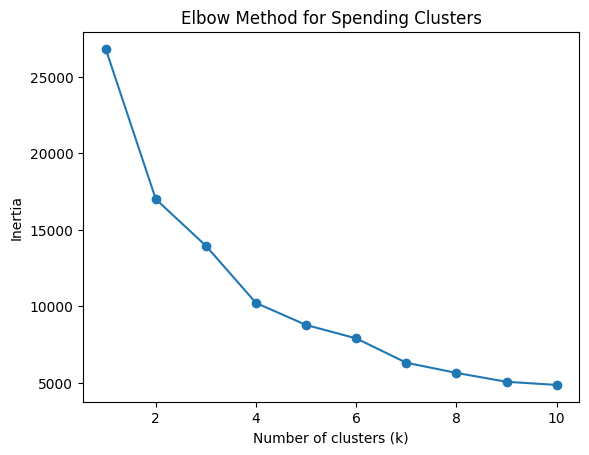

In [20]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Spending Clusters")
plt.show()

In [21]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.549
k=3, silhouette score=0.436
k=4, silhouette score=0.455
k=5, silhouette score=0.463
k=6, silhouette score=0.417


#### Even though k=2 performs best from a purely numerical perspective, it ends up being a bit too simplistic and doesn't capture the differences between customers in a meaningful way.
#### Between k=4 and k=5, the performance is very similar. However, k=4 provides a more balanced and interpretable segmentation without overcomplicating the model.
#### Therefore, k=4 was chosen for further analysis.

In [22]:
kmeans_spending = KMeans(n_clusters=4, random_state=42)
df["spending_cluster"] = kmeans_spending.fit_predict(X_scaled)

In [23]:
df["spending_cluster"].value_counts()

spending_cluster
1    5763
0    2014
3    1060
2     106
Name: count, dtype: int64

#### The distribution is uneven, where cluster 2 is small and cluster 1 have over half of the customers. 

In [24]:
df.groupby("spending_cluster")[features_spending].mean()

,purchases,balance,credit_limit
spending_cluster,,,
0,1701.373640,1112.773691,7810.420240
1,500.510760,849.811454,2330.806389
2,14547.543019,4413.802366,12209.905660
3,1061.176906,6031.422463,9189.862779


In [25]:
cluster_names_spending = {
    0: "Stable spenders",
    1: "Ghost mode",
    2: "VIP big spenders",
    3: "Risky balance customers"
}

df["spending_cluster_name"] = df["spending_cluster"].map(cluster_names_spending) # map cluster labels to descriptive names for better interpretability

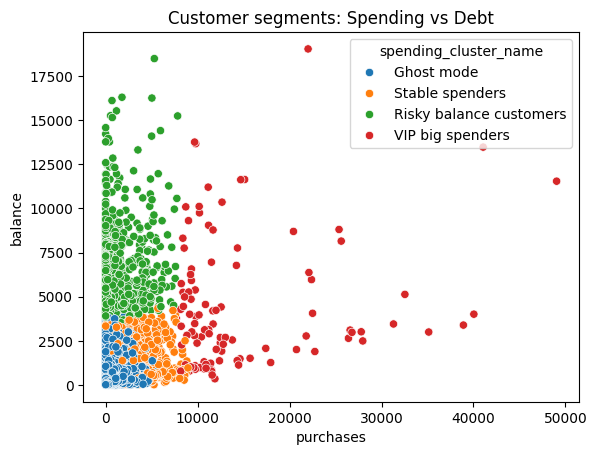

In [26]:
sns.scatterplot(
    data=df,
    x="purchases",
    y="balance",
    hue="spending_cluster_name"
)

plt.title("Customer segments: Spending vs Debt")
plt.show()

#### Even though VIP big spenders cluster is small it´s pretty clear it´s needs to be in it own cluster because the customers behaviors doesn´t match the other clusters

### Clutser to show the active and passive customers depending on how they use their card 

In [27]:
features_usage = ["oneoff_purchases", "installments_purchases", "cash_advance"]

X = df[features_usage] # using relevant features for clustering in this case - customer usage related features

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

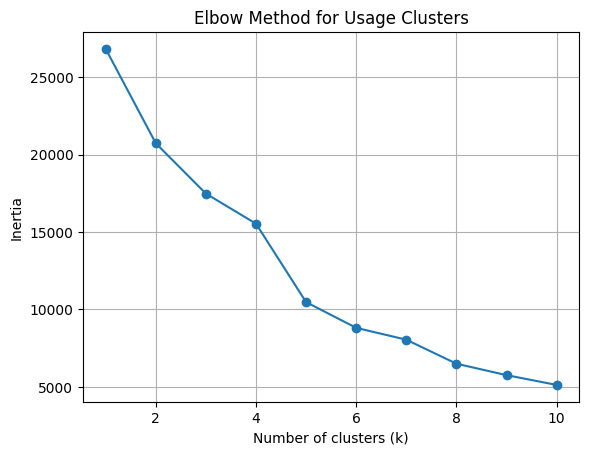

In [29]:
inertia = []

k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Usage Clusters")
plt.grid()
plt.show()

In [30]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.723
k=3, silhouette score=0.591
k=4, silhouette score=0.497
k=5, silhouette score=0.566
k=6, silhouette score=0.546


#### From the silhouette score you can tell that k=3 is the best model, k=2 have the higher score but you don´t want a to simplyfied model that can loose som of the customers charactisics. It also look like k=3 is the best according to the elbow method. 

In [31]:
kmeans_usage = KMeans(n_clusters=3, random_state=42)
df["usage_cluster"] = kmeans_usage.fit_predict(X_scaled)

In [32]:
df["usage_cluster"].value_counts()

usage_cluster
1    8044
0     874
2      25
Name: count, dtype: int64

In [33]:
df.groupby("usage_cluster")[features_usage].mean()

,oneoff_purchases,installments_purchases,cash_advance
usage_cluster,,,
0,2442.413627,2045.795092,665.001673
1,328.303907,215.898292,1013.974274
2,21070.723600,6140.669200,892.501633


#### Cluster 2 is a very small cluster with only 25 customers but have very high values on oneoff_purchases and installments_purchases but low in cash_advance. It makes them a valued customer for the bank

In [34]:
cluster_names_usage = {
    0: "Balanced spenders",
    1: "Cash advance heavy",
    2: "Power users"
}

df["usage_cluster_name"] = df["usage_cluster"].map(cluster_names_usage) # map cluster labels to descriptive names for better interpretability

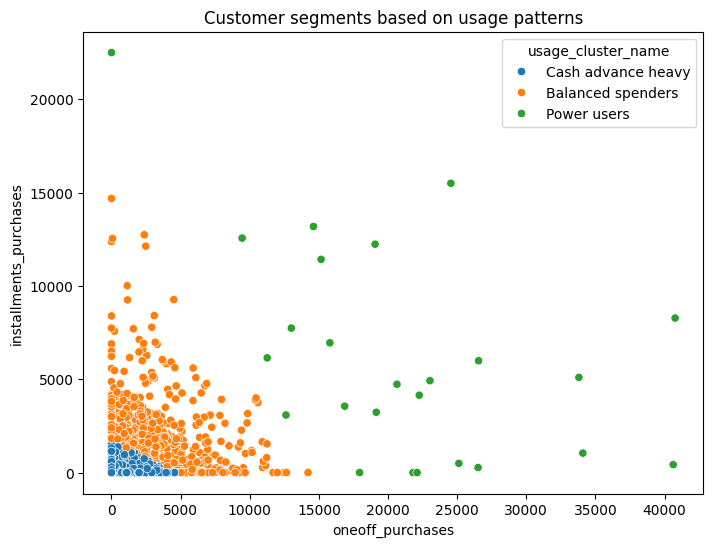

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="oneoff_purchases",
    y="installments_purchases",
    hue="usage_cluster_name"
)
plt.title("Customer segments based on usage patterns")
plt.show()

### Put the diffrent clusters in to a excel file

In [38]:

# define the diffrent cluster names for each clustering dimension for better interpretability when we export the data to Excel
cluster_names_activity = {
    0: "Ride or die customers",
    1: "Ghost mode",
    2: "Treat yourself sometimes",
    3: "VIP big spenders"
}

cluster_names_spending = {
    0: "Stable spenders",
    1: "Ghost mode",
    2: "VIP big spenders",
    3: "Risky balance customers"
}

cluster_names_usage = {
    0: "Balanced spenders",
    1: "Cash advance heavy",
    2: "Power users"
}

# Map cluster names to the respective cluster labels in the dataframe for better interpretability when we export the data to Excel

df["activity_cluster_name"] = df["activity_cluster"].map(cluster_names_activity)
df["spending_cluster_name"] = df["spending_cluster"].map(cluster_names_spending)
df["usage_cluster_name"] = df["usage_cluster"].map(cluster_names_usage)

# export the dataframe with cluster labels and names to Excel for further analysis and reporting

df.to_excel("bank_data_clustered.xlsx", index=False)

### Cluster with PCA